In [1]:
import numpy as np
import pandas as pd
import time
import os
import random
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

import elkai
import tsplib95
from scipy.spatial.distance import cdist
from scipy.stats import skew, kurtosis
from scipy.sparse.csgraph import minimum_spanning_tree

from mealpy import GA, SA, PSO, ACOR
from mealpy.utils.problem import Problem
from mealpy.utils.space import FloatVar

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

class TSPProblem(Problem):
    def __init__(self, D, **kwargs):
        self.D = D
        self.n = len(D)
        bounds = FloatVar(lb=[0.0] * self.n, ub=[self.n - 1.0] * self.n)
        super().__init__(
            bounds=bounds,
            minmax="min",
            **kwargs
        )

    def obj_func(self,x):
        tour = np.argsort(x).tolist()
        cost = sum(self.D[tour[i]][tour[i+1]] for i in range(self.n - 1))
        cost += self.D[tour[-1]][tour[0]]
        return cost

def two_opt(tour, D):
    n = len(tour)
    improved = True
    while improved:
        improved = False
        for i in range(1, n-1):
            for j in range(i+1, n):
                a, b = tour[i-1], tour[i]
                c, d = tour[j], tour[(j+1) % n]
                if D[a][b] + D[c][d] > D[a][c] + D[b][d]:
                    tour[i:j+1] = tour[i:j+1][::-1]
                    improved = True
    return tour


In [2]:
def run_mealpy(model,D):
    problem = TSPProblem(D=D, log_to=None)
    t0 = time.time()
    model.solve(problem)
    runtime = time.time() - t0
    best_x = model.g_best.solution
    tour = np.argsort(best_x).tolist()
    tour = two_opt(tour, D)
    cost = sum(D[tour[i]][tour[i+1]] for i in range(len(tour)-1)) + D[tour[-1]][tour[0]]
    history = model.history.list_global_best_fit
    return cost, runtime, history

def run_lk(D):
    D_int = (D * 1000).astype(int).tolist()
    t0 = time.time()
    tour = elkai.solve_int_matrix(D_int)
    runtime = time.time() - t0
    cost = sum(D[tour[i]][tour[i+1]] for i in range(len(tour) - 1)) + D[tour[-1]][tour[0]]
    return cost, runtime, None

In [3]:
def get_algo_pool(n):
    if n<=30:
        epochs, pop = 200,100
    elif n<=75:
        epochs, pop = 300,100
    elif n<=100:
        epochs, pop = 400,100
    else:
        epochs, pop = 500,150
        
    return {
        "OGA": lambda D, e=epochs, p=pop: run_mealpy(GA.OriginalGA(epoch=e, pop_size=p), D),
        "SA":  lambda D, e=epochs: run_mealpy(SA.OriginalSA(epoch=e, pop_size=10), D),
        "LK":  lambda D: run_lk(D),
        "PSO": lambda D, e=epochs, p=pop: run_mealpy(PSO.OriginalPSO(epoch=e, pop_size=p), D),
        #"ACO": lambda D, e=epochs, p=pop: run_mealpy(ACOR.OriginalACOR(epoch=e, pop_size=p), D)
        
    }


In [4]:
def compute_distance_matrix(coords, distance_type="euclidean"):
    n = len(coords)
    D = np.zeros((n,n))

    if distance_type == "euclidean":
        D = cdist(coords, coords, metric='euclidean')

    elif distance_type == "manhattan":
        D = cdist(coords, coords, metric="cityblock")

    elif distance_type == "chebyshev":
        D = cdist(coords, coords, metric="chebyshev")

    elif distance_type == "ceil_euclidean":
        D = np.ceil(cdist(coords, coords, metric="euclidean"))

    else:
        raise ValueError(f"Unsupported distance type: {distance_type}")
        
    np.fill_diagonal(D, 0)
    return D

DISTANCE_TYPE = {
    "euclidean": 0,
    "manhattan": 1,
    "chebyshev": 2,
    "ceil_euclidean": 3
}

In [5]:
def generate_instance(n, distribution, seed, distance_type="euclidean", noise_factor=0.0, instance_type="standard"):
    rng = np.random.default_rng(seed)

    if instance_type == "random_cost":
        D = rng.uniform(100, 1000, (n,n))
        D = (D+D.T)/2
        np.fill_diagonal(D,0)
        coords = None

    elif instance_type == "triangle_violation":
        coords = rng.uniform(0,1000,(n,2))
        D = cdist(coords, coords, metric="euclidean")
        max_original = D.max()
        for _ in range (int(n*n*0.3)):
            i, j, k = rng.choice(n,3, replace=False)
            if D[i][j] <= D[i][k] + D[k][j]:
                new_val = (D[i][k] + D[k][j]) * rng.uniform(1.1, 1.5)
                D[i][j] = min(new_val, max_original * 3)
                D[j][i] = D[i][j]
        np.fill_diagonal(D,0)
        return coords, D

    if distribution == "uniform":
        coords = rng.uniform(0, 1000, (n,2))

    elif distribution == "clustered":
        centers = rng.uniform(100, 900, (max(2, n//10),2))
        coords = np.array([centers[i % max(2, n//10)] + rng.normal(0,30,2) for i in range(n)])

    elif distribution == "grid":
        side = int(np.ceil(np.sqrt(n)))
        coords = np.array([[x,y] for x in range(side) for y in range(side)])[:n] * (1000/side)

    elif distribution == "diagonal":
        t = rng.uniform(0, 1000, n)
        noise = rng.normal(0,20,(n,2))
        coords = np.column_stack([t, t]) + noise

    D = compute_distance_matrix(coords, distance_type)
    
    if noise_factor > 0.0:
        noise = rng.uniform(0,noise_factor,(n,n))
        noise = (noise + noise.T)/2
        np.fill_diagonal(noise, 0)
        D = D + noise * D.mean()
        np.fill_diagonal(D,0)

    return coords, D

INSTANCE_TYPE = {
    "standard": 0,
    "random_cost": 1,
    "triangle_violation": 2
}

In [6]:
def load_tsplib(name, folder="./tsplib"):
    problem = tsplib95.load(os.path.join(folder, f"{name}.tsp"))
    n = problem.dimension
    nodes = list(problem.get_nodes())

    D = np.zeros((n, n))
    for i in nodes:
        for j in nodes:
            D[i-1][j-1] = problem.get_weight(i, j)

    coords = None
    if problem.node_coords:
        coords = np.array([problem.node_coords[i] for i in nodes])

    return coords, D

In [7]:
def extract_features(coords, D, distance_type, noise_factor, instance_type):
    n = len(D)
    upper = D[np.triu_indices(n, k=1)]

    D_nn = D.copy()
    np.fill_diagonal(D_nn, np.inf)
    nn = D_nn.min(axis=1)

    mst_arr = minimum_spanning_tree(D).toarray()
    mst_vals = mst_arr[mst_arr > 0]
    
    violations = 0
    checks = 0
    for i in range(min(n,20)):
        for j in range(min(n,20)):
            for k in range(min(n,20)):
                if i!=j and j!=k and i!=k:
                    if D[i][j] > D[i][k] + D[k][j]:
                        violations += 1
                    checks += 1

    features = {
        "n_cities": n,
        "noise_factor": noise_factor,
        "distance_type": DISTANCE_TYPE.get(distance_type, -1),
        "triangle_violation_rate": violations / checks if checks > 0 else 0,
        "instance_type": INSTANCE_TYPE.get(instance_type, -1),
        "avg_edge": upper.mean(),
        "std_edge": upper.std(),
        "cv_edge": upper.std() / upper.mean(),
        "skew_edge": float(skew(upper)),
        "kurtosis_edge": float(kurtosis(upper)),
        "min_edge": upper.min(),
        "max_edge": upper.max(),

        "avg_nn": nn.mean(),
        "std_nn": nn.std(),
        "cv_nn": nn.std() / nn.mean(),
        "skew_nn": float(skew(nn)),

        "mst_cost": mst_vals.sum(),
        "avg_mst_edge": mst_vals.mean(),
        "std_mst_edge": mst_vals.std(),
        "mst_nn_ratio": mst_vals.mean() / nn.mean()
    }

    if coords is not None:
        centroid = coords.mean(axis=0)
        centroid_dists = np.linalg.norm(coords - centroid, axis=1)

        x_range = coords[:, 0].max() - coords[:, 0].min()
        y_range = coords[:, 1].max() - coords[:, 1].min()

        features.update({
            "avg_centroid_dist": centroid_dists.mean(),
            "std_centroid_dist": centroid_dists.std(),
            "cv_centroid_dist": centroid_dists.std() / centroid_dists.mean(),
            "bbox_area": x_range * y_range,
            "bbox_ratio": x_range / (y_range +1e-9)
        })

    else:
        for col in ["avg_centroid_dist","std_centroid_dist",
                    "cv_centroid_dist","bbox_area","bbox_ratio"]:
            features[col] = np.nan
        
    return features


In [8]:
def solve_concorde(coords, D=None):
    try:
        from concorde.tsp import TSPSolver
        solver = TSPSolver.from_data(
            coords[:, 0].tolist(),
            coords[:, 1].tolist(),
            norm = "EUC_2D"
        )
        solution = solver.solve(verbose=False)
        tour = list(solution.tour)
        if D is None:
            D = cdist(coords, coords)
        cost = sum(D[tour[i]][tour[i+1]] for i in range(len(tour)-1)) + D[tour[-1]][tour[0]]
        
        return cost
    except ImportError:
        return None

In [9]:
def run_all(D, coords=None, n_runs=3, use_concorde=False):
    n = len(D)
    results = {}
    pool = get_algo_pool(n)

    for name, algo_fn  in pool.items():
        run_costs = []
        run_times = []

        for _ in range(n_runs):
            cost, runtime, _ = algo_fn(D)
            run_costs.append(cost)
            run_times.append(runtime)
        results[name] = {
            "best_cost": min(run_costs),
            "avg_cost": np.mean(run_costs),
            "std_cost": np.std(run_costs),
            "avg_time": np.mean(run_times),
        }

    optimal = None
    if use_concorde and coords is not None and len(D) <= 150:
        optimal = solve_concorde(coords, D=D)

    return results, optimal

In [10]:
def validate_tour(tour, n):
    if len(tour)!=n:
        return False, f"Tour length {len(tour)} does not match n={n}"

    expected = set(range(n))
    actual = set(tour)

    if actual!=expected:
        missing = expected - actual
        extra = actual - expected
        msh = ""
        if missing:
            msg += f"Missing cities: {missing}"
        if extra:
            msg += f"Invalid cities: {extra}"
        return False, msg
    if len(tour) != len(set(tour)):
        duplicates = [c for c in tour if tour.count(c) > 1]
        return False, f"Duplicate cities: {set(duplicates)}"
    
    return True, "Valid"

In [11]:
def build_row(coords, D, source, label, n_runs=3, use_concorde=False, 
              distance_type="euclidean", noise_factor=0.0, instance_type="standard"):
    features = extract_features(coords, D,
                               distance_type=distance_type,
                               noise_factor=noise_factor,
                               instance_type=instance_type)
    algo_results, optimal = run_all(
        D, coords, n_runs=n_runs, use_concorde=use_concorde
    )

    best_algo = min(algo_results, key=lambda k: algo_results[k]["best_cost"])

    row = {
        **features,
        "source": source,
        "label": label,
        "best_algo": best_algo,
        "optimal": optimal,
    }

    for algo, metrics in algo_results.items():
        for metric, val in metrics.items():
            row[f"{algo}_{metric}"] = val

        if optimal:
            row[f"{algo}_gap"] = ((algo_results[algo]["best_cost"] - optimal) / optimal)
    return row
    
def build_dataset(configs, source="generated", use_concorde=False, output_file=None):
    rows=[]
    for i, cfg in enumerate(configs):
        if source == "generated":
            coords, D = generate_instance(
                cfg["n"], cfg["distribution"], cfg["seed"], distance_type=cfg.get("distance_type", "euclidean"),
                noise_factor=cfg.get("noise_factor",0.0), instance_type=cfg.get("instance_type", "standard")
            )
            label = (f"{cfg['distribution']}_{cfg['n']}_{cfg['seed']}_"
                    f"{cfg.get('distance_type','euclidean')}_"
                    f"{cfg.get('instance_type', 'standard')}")
        else:
            coords, D = load_tsplib(cfg["name"])
            label = cfg["name"]
        
        row = build_row(
            coords, D,
            source=source,
            label=label,
            use_concorde=use_concorde,
            distance_type=cfg.get("distance_type", "euclidean"),
            noise_factor=cfg.get('noise_factor',0.0),
            instance_type=cfg.get("instance_type", "standard")
        )
        rows.append(row)
        print(f"[{i+1}/{len(configs)}] {label} -> best: {row['best_algo']}")
        
    pd.DataFrame(rows).to_csv(output_file, index=False)
    return pd.DataFrame(rows)



# Validation


In [12]:
def run_mealpy_val(model,D):
    problem = TSPProblem(D=D, log_to=None)
    t0 = time.time()
    model.solve(problem)
    runtime = time.time() - t0
    best_x = model.g_best.solution
    tour = np.argsort(best_x).tolist()
    tour = two_opt(tour, D)
    cost = sum(D[tour[i]][tour[i+1]] for i in range(len(tour)-1)) + D[tour[-1]][tour[0]]
    history = model.history.list_global_best_fit
    return cost, runtime, history, tour

def run_lk_val(D):
    D_int = (D * 1000).astype(int).tolist()
    t0 = time.time()
    tour = elkai.solve_int_matrix(D_int)
    runtime = time.time() - t0
    cost = sum(D[tour[i]][tour[i+1]] for i in range(len(tour) - 1)) + D[tour[-1]][tour[0]]
    return cost, runtime, None, tour

def get_algo_pool_val(n):
    if n<=30:
        epochs, pop = 200,100
    elif n<=75:
        epochs, pop = 300,75
    elif n<=100:
        epochs, pop = 400,100
    elif n<=150:
        epochs, pop = 500,150
    else:
        epochs, pop = 800,200
        
    return {
        "OGA": lambda D, e=epochs, p=pop: run_mealpy_val(GA.OriginalGA(epoch=e, pop_size=p), D),
        "SA":  lambda D, e=epochs: run_mealpy_val(SA.OriginalSA(epoch=e, pop_size=10), D),
        "LK":  lambda D: run_lk_val(D),
        "PSO": lambda D, e=epochs, p=pop: run_mealpy_val(PSO.OriginalPSO(epoch=e, pop_size=p), D),
        #"ACO": lambda D, e=epochs, p=pop: run_mealpy_val(ACOR.OriginalACOR(epoch=e, pop_size=p), D),
    }
def test_solvers(n=20, distribution='uniform', seed=0,tsplib_name=None,
                 distance_type="euclidean", noise_factor=0.0, instance_type="standard"):
    
    if tsplib_name is not None:
        coords, D = coords, D = load_tsplib(tsplib_name)
        n = len(D)
        label = tsplib_name
    else:
        coords, D = generate_instance(n, distribution, seed, distance_type=distance_type,
                                      noise_factor=noise_factor, instance_type=instance_type)
    pool = get_algo_pool_val(n)
    print(f"\nTesting  on {distribution} instance, n={n}")
    print('-'*50)

    for name, algo_fn in pool.items():
        cost, runtime, _, tour = algo_fn(D)
        is_valid, msg = validate_tour(tour,n)
        print(f"{name:6} | valid={is_valid} | cost={cost:.2f} | runtime={runtime}| {msg}")
        
test_solvers(n=10, distribution="uniform", seed=0, instance_type="triangle_violation")
test_solvers(n=15, distribution="uniform", seed=0, instance_type="triangle_violation")
test_solvers(n=20, distribution="uniform", seed=0, instance_type="triangle_violation")
test_solvers(n=20, distribution="clustered", seed=0, noise_factor=0.2)
test_solvers(n=20, distribution="grid", seed=0, distance_type="manhattan")
test_solvers(n=50, distribution="diagonal", seed=0, instance_type="random_cost")

#test_solvers(tsplib_name="eil51")
#test_solvers(tsplib_name="berlin52")
#test_solvers(tsplib_name="st70")
#test_solvers(tsplib_name="bays29")


Testing  on uniform instance, n=10
--------------------------------------------------
OGA    | valid=True | cost=5985.35 | runtime=0.023916006088256836| Valid
SA     | valid=True | cost=5606.84 | runtime=0.033811092376708984| Valid
LK     | valid=True | cost=4682.12 | runtime=0.012721538543701172| Valid
PSO    | valid=True | cost=4682.12 | runtime=0.66391921043396| Valid

Testing  on uniform instance, n=15
--------------------------------------------------
OGA    | valid=True | cost=6097.12 | runtime=0.022357702255249023| Valid
SA     | valid=True | cost=5882.35 | runtime=0.01877140998840332| Valid
LK     | valid=True | cost=5374.80 | runtime=0.017009258270263672| Valid
PSO    | valid=True | cost=6511.82 | runtime=0.7543728351593018| Valid

Testing  on uniform instance, n=20
--------------------------------------------------
OGA    | valid=True | cost=6485.79 | runtime=0.022685527801513672| Valid
SA     | valid=True | cost=6687.67 | runtime=0.016132831573486328| Valid
LK     | valid=T

In [14]:
train_configs_10_20 = [
    {"n": n, "distribution": d, "seed": s, "distance_type": dt, "noise_factor": nf, "instance_type": it}
    for n in [10,20]
    for d in ["uniform","clustered", "grid","diagonal"]
    for s in range(10)
    for dt in ["euclidean","manhattan","ceil_euclidean","chebyshev"]
    for nf in [0.0, 0.1, 0.2]
    for it in ["random_cost","triangle_violation"]
]

train_configs_50 = [
    {"n": n, "distribution": d, "seed": s, "distance_type": dt, "noise_factor": nf, "instance_type": it}
    for n in [50]
    for d in ["uniform","clustered", "grid","diagonal"]
    for s in range(10)
    for dt in ["euclidean","manhattan","ceil_euclidean","chebyshev"]
    for nf in [0.0, 0.1, 0.2]
    for it in ["random_cost","triangle_violation"]
    for asym in [True,False]
]

train_configs_75 = [
    {"n": n, "distribution": d, "seed": s, "distance_type": dt, "noise_factor": nf, "instance_type": it}
    for n in [75]
    for d in ["uniform","clustered", "grid","diagonal"]
    for s in range(10)
    for dt in ["euclidean","manhattan","ceil_euclidean","chebyshev"]
    for nf in [0.0, 0.1, 0.2]
    for it in ["random_cost","triangle_violation"]
]

train_configs_100 = [
    {"n": n, "distribution": d, "seed": s, "distance_type": dt, "noise_factor": nf, "instance_type": it}
    for n in [100]
    for d in ["uniform","clustered", "grid","diagonal"]
    for s in range(10)
    for dt in ["euclidean","manhattan","ceil_euclidean","chebyshev"]
    for nf in [0.0, 0.1, 0.2]
    for it in ["random_cost","triangle_violation"]
]


In [23]:
build_dataset(train_configs_10_20, source="generated", use_concorde=False, output_file="train_10_20.csv")

[1/1920] uniform_10_0_euclidean_random_cost -> best: OGA
[2/1920] uniform_10_0_euclidean_triangle_violation -> best: LK
[3/1920] uniform_10_0_euclidean_random_cost -> best: OGA
[4/1920] uniform_10_0_euclidean_triangle_violation -> best: SA
[5/1920] uniform_10_0_euclidean_random_cost -> best: PSO
[6/1920] uniform_10_0_euclidean_triangle_violation -> best: SA
[7/1920] uniform_10_0_manhattan_random_cost -> best: OGA
[8/1920] uniform_10_0_manhattan_triangle_violation -> best: LK
[9/1920] uniform_10_0_manhattan_random_cost -> best: OGA
[10/1920] uniform_10_0_manhattan_triangle_violation -> best: LK
[11/1920] uniform_10_0_manhattan_random_cost -> best: PSO
[12/1920] uniform_10_0_manhattan_triangle_violation -> best: LK
[13/1920] uniform_10_0_ceil_euclidean_random_cost -> best: OGA
[14/1920] uniform_10_0_ceil_euclidean_triangle_violation -> best: LK
[15/1920] uniform_10_0_ceil_euclidean_random_cost -> best: PSO
[16/1920] uniform_10_0_ceil_euclidean_triangle_violation -> best: LK
[17/1920] uni

/tmp/ipykernel_24946/3902276500.py:39: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  "skew_nn": float(skew(nn)),


[481/1920] grid_10_0_euclidean_random_cost -> best: OGA
[482/1920] grid_10_0_euclidean_triangle_violation -> best: LK
[483/1920] grid_10_0_euclidean_random_cost -> best: PSO
[484/1920] grid_10_0_euclidean_triangle_violation -> best: LK
[485/1920] grid_10_0_euclidean_random_cost -> best: SA
[486/1920] grid_10_0_euclidean_triangle_violation -> best: SA
[487/1920] grid_10_0_manhattan_random_cost -> best: SA
[488/1920] grid_10_0_manhattan_triangle_violation -> best: OGA
[489/1920] grid_10_0_manhattan_random_cost -> best: OGA
[490/1920] grid_10_0_manhattan_triangle_violation -> best: LK
[491/1920] grid_10_0_manhattan_random_cost -> best: OGA
[492/1920] grid_10_0_manhattan_triangle_violation -> best: LK
[493/1920] grid_10_0_ceil_euclidean_random_cost -> best: OGA
[494/1920] grid_10_0_ceil_euclidean_triangle_violation -> best: LK
[495/1920] grid_10_0_ceil_euclidean_random_cost -> best: SA
[496/1920] grid_10_0_ceil_euclidean_triangle_violation -> best: LK
[497/1920] grid_10_0_ceil_euclidean_ra

,n_cities,noise_factor,distance_type,triangle_violation_rate,instance_type,avg_edge,std_edge,cv_edge,skew_edge,kurtosis_edge,...,SA_std_cost,SA_avg_time,LK_best_cost,LK_avg_cost,LK_std_cost,LK_avg_time,PSO_best_cost,PSO_avg_cost,PSO_std_cost,PSO_avg_time
0,10,0.0,0,0.000000,1,595.698975,277.547799,0.465920,0.009372,-1.116216,...,2.625485e-13,0.015345,2940.041676,2940.041676,0.000000e+00,0.005318,2940.041676,2940.041676,2.625485e-13,0.651109
1,10,0.0,0,0.208333,2,1629.643045,1149.079322,0.705111,0.616437,-1.044734,...,5.250970e-13,0.017226,4682.118054,4682.118054,0.000000e+00,0.005545,4682.118054,4682.118054,7.425993e-13,0.648394
2,10,0.1,0,0.000000,1,623.356820,277.059482,0.444464,0.038744,-1.127442,...,4.547474e-13,0.017434,3243.555563,3243.555563,4.547474e-13,0.006146,3243.555563,3243.555563,6.431099e-13,0.636684
3,10,0.1,0,0.208333,2,1629.643045,1149.079322,0.705111,0.616437,-1.044734,...,5.691871e+02,0.016365,4682.118054,4682.118054,0.000000e+00,0.005238,4682.118054,4990.358431,4.359177e+02,0.674936
4,10,0.2,0,0.000000,1,651.014664,277.029516,0.425535,0.065891,-1.133819,...,4.547474e-13,0.017878,3547.069451,3547.069451,4.547474e-13,0.005212,3547.069451,3547.069451,4.547474e-13,0.643783
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1915,20,0.0,2,0.206433,2,1416.781265,1166.851733,0.823593,0.903504,-0.602433,...,2.653392e+02,0.035262,5693.665008,5693.665008,9.094947e-13,0.029706,5876.007042,6029.437646,1.455087e+02,0.791907
1916,20,0.1,2,0.005263,1,397.027715,249.105738,0.627427,0.444126,-0.912146,...,6.108304e+00,0.017042,2533.187723,2533.187723,0.000000e+00,0.037189,2533.745438,2539.146791,3.819333e+00,0.974015
1917,20,0.1,2,0.206433,2,1416.781265,1166.851733,0.823593,0.903504,-0.602433,...,2.430937e+02,0.021256,5693.665008,5693.665008,9.094947e-13,0.032243,6133.646537,6490.787696,4.352238e+02,0.952424
1918,20,0.2,2,0.005556,1,414.812698,248.689528,0.599522,0.444439,-0.902505,...,7.439507e+00,0.022367,2881.033916,2881.033916,0.000000e+00,0.063678,2880.609767,2891.867728,7.962463e+00,0.877820


In [13]:
build_dataset(train_configs_50, source="generated", use_concorde=False, output_file="train_50.csv")

[1/1920] uniform_50_0_euclidean_random_cost -> best: LK
[2/1920] uniform_50_0_euclidean_random_cost -> best: LK
[3/1920] uniform_50_0_euclidean_triangle_violation -> best: LK
[4/1920] uniform_50_0_euclidean_triangle_violation -> best: LK
[5/1920] uniform_50_0_euclidean_random_cost -> best: PSO
[6/1920] uniform_50_0_euclidean_random_cost -> best: LK
[7/1920] uniform_50_0_euclidean_triangle_violation -> best: LK
[8/1920] uniform_50_0_euclidean_triangle_violation -> best: LK
[9/1920] uniform_50_0_euclidean_random_cost -> best: LK
[10/1920] uniform_50_0_euclidean_random_cost -> best: LK
[11/1920] uniform_50_0_euclidean_triangle_violation -> best: LK
[12/1920] uniform_50_0_euclidean_triangle_violation -> best: LK
[13/1920] uniform_50_0_manhattan_random_cost -> best: LK
[14/1920] uniform_50_0_manhattan_random_cost -> best: LK
[15/1920] uniform_50_0_manhattan_triangle_violation -> best: LK
[16/1920] uniform_50_0_manhattan_triangle_violation -> best: LK
[17/1920] uniform_50_0_manhattan_random_

/tmp/ipykernel_1611/3902276500.py:39: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  "skew_nn": float(skew(nn)),


[961/1920] grid_50_0_euclidean_random_cost -> best: LK
[962/1920] grid_50_0_euclidean_random_cost -> best: LK
[963/1920] grid_50_0_euclidean_triangle_violation -> best: LK
[964/1920] grid_50_0_euclidean_triangle_violation -> best: LK
[965/1920] grid_50_0_euclidean_random_cost -> best: LK
[966/1920] grid_50_0_euclidean_random_cost -> best: LK
[967/1920] grid_50_0_euclidean_triangle_violation -> best: LK
[968/1920] grid_50_0_euclidean_triangle_violation -> best: LK
[969/1920] grid_50_0_euclidean_random_cost -> best: LK
[970/1920] grid_50_0_euclidean_random_cost -> best: LK
[971/1920] grid_50_0_euclidean_triangle_violation -> best: LK
[972/1920] grid_50_0_euclidean_triangle_violation -> best: LK
[973/1920] grid_50_0_manhattan_random_cost -> best: LK
[974/1920] grid_50_0_manhattan_random_cost -> best: LK
[975/1920] grid_50_0_manhattan_triangle_violation -> best: LK
[976/1920] grid_50_0_manhattan_triangle_violation -> best: LK
[977/1920] grid_50_0_manhattan_random_cost -> best: LK
[978/1920

,n_cities,noise_factor,distance_type,triangle_violation_rate,instance_type,avg_edge,std_edge,cv_edge,skew_edge,kurtosis_edge,...,SA_std_cost,SA_avg_time,LK_best_cost,LK_avg_cost,LK_std_cost,LK_avg_time,PSO_best_cost,PSO_avg_cost,PSO_std_cost,PSO_avg_time
0,50,0.0,0,0.000000,1,539.513805,251.422019,0.466016,0.145777,-0.717523,...,176.477761,0.025269,5316.983105,5316.983105,0.0,0.201476,5772.774463,5957.763655,185.540861,1.276065
1,50,0.0,0,0.000000,1,539.513805,251.422019,0.466016,0.145777,-0.717523,...,342.774983,0.030911,5316.983105,5316.983105,0.0,0.201252,5723.617332,5913.523748,217.484394,1.820267
2,50,0.0,0,0.207310,2,1409.298156,1229.898986,0.872703,1.089602,-0.103573,...,505.984932,0.028416,8297.870817,8297.870817,0.0,0.310557,9102.452962,9293.108014,188.360922,1.260500
3,50,0.0,0,0.207310,2,1409.298156,1229.898986,0.872703,1.089602,-0.103573,...,17.530722,0.026663,8297.870817,8297.870817,0.0,0.279929,8919.568652,9232.949349,223.922653,1.144663
4,50,0.1,0,0.001754,1,566.031233,251.196022,0.443785,0.144875,-0.708832,...,113.497321,0.024065,6624.275905,6624.275905,0.0,0.220971,6624.275905,6978.607520,280.119175,1.391842
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1915,50,0.1,2,0.199415,2,1314.388817,1129.020148,0.858970,1.131855,0.041797,...,597.061770,0.029813,8090.026200,8090.026200,0.0,0.196227,9589.823656,9748.252633,141.348155,1.463391
1916,50,0.2,2,0.011988,1,390.854736,241.540456,0.617980,0.584559,-0.482199,...,45.693368,0.031584,3974.588370,3974.588370,0.0,0.524885,4004.620201,4024.616077,20.111025,1.476229
1917,50,0.2,2,0.011988,1,390.854736,241.540456,0.617980,0.584559,-0.482199,...,36.764191,0.030334,3974.588370,3974.588370,0.0,0.515759,4004.339592,4044.922778,33.830294,1.906838
1918,50,0.2,2,0.199415,2,1314.388817,1129.020148,0.858970,1.131855,0.041797,...,599.665844,0.028443,8090.026200,8090.026200,0.0,0.189367,8975.589031,9442.765233,345.106702,1.377863


In [25]:
build_dataset(train_configs_75, source="generated", use_concorde=False, output_file="train_75.csv")

[1/960] uniform_75_0_euclidean_random_cost -> best: LK
[2/960] uniform_75_0_euclidean_triangle_violation -> best: LK
[3/960] uniform_75_0_euclidean_random_cost -> best: LK
[4/960] uniform_75_0_euclidean_triangle_violation -> best: LK
[5/960] uniform_75_0_euclidean_random_cost -> best: LK
[6/960] uniform_75_0_euclidean_triangle_violation -> best: LK
[7/960] uniform_75_0_manhattan_random_cost -> best: LK
[8/960] uniform_75_0_manhattan_triangle_violation -> best: LK
[9/960] uniform_75_0_manhattan_random_cost -> best: LK
[10/960] uniform_75_0_manhattan_triangle_violation -> best: LK
[11/960] uniform_75_0_manhattan_random_cost -> best: LK
[12/960] uniform_75_0_manhattan_triangle_violation -> best: LK
[13/960] uniform_75_0_ceil_euclidean_random_cost -> best: LK
[14/960] uniform_75_0_ceil_euclidean_triangle_violation -> best: LK
[15/960] uniform_75_0_ceil_euclidean_random_cost -> best: LK
[16/960] uniform_75_0_ceil_euclidean_triangle_violation -> best: LK
[17/960] uniform_75_0_ceil_euclidean_

/tmp/ipykernel_1762/3902276500.py:39: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  "skew_nn": float(skew(nn)),


[481/960] grid_75_0_euclidean_random_cost -> best: LK
[482/960] grid_75_0_euclidean_triangle_violation -> best: LK
[483/960] grid_75_0_euclidean_random_cost -> best: LK
[484/960] grid_75_0_euclidean_triangle_violation -> best: LK
[485/960] grid_75_0_euclidean_random_cost -> best: LK
[486/960] grid_75_0_euclidean_triangle_violation -> best: LK
[487/960] grid_75_0_manhattan_random_cost -> best: LK
[488/960] grid_75_0_manhattan_triangle_violation -> best: LK
[489/960] grid_75_0_manhattan_random_cost -> best: LK
[490/960] grid_75_0_manhattan_triangle_violation -> best: LK
[491/960] grid_75_0_manhattan_random_cost -> best: LK
[492/960] grid_75_0_manhattan_triangle_violation -> best: LK
[493/960] grid_75_0_ceil_euclidean_random_cost -> best: LK
[494/960] grid_75_0_ceil_euclidean_triangle_violation -> best: LK
[495/960] grid_75_0_ceil_euclidean_random_cost -> best: LK
[496/960] grid_75_0_ceil_euclidean_triangle_violation -> best: LK
[497/960] grid_75_0_ceil_euclidean_random_cost -> best: LK
[

,n_cities,noise_factor,distance_type,triangle_violation_rate,instance_type,avg_edge,std_edge,cv_edge,skew_edge,kurtosis_edge,...,SA_std_cost,SA_avg_time,LK_best_cost,LK_avg_cost,LK_std_cost,LK_avg_time,PSO_best_cost,PSO_avg_cost,PSO_std_cost,PSO_avg_time
0,75,0.0,0,0.000000,1,502.186874,242.731839,0.483350,0.313081,-0.546283,...,75.249754,0.037504,7158.989452,7158.989452,0.000000e+00,0.660472,7756.702161,7789.269863,35.871756,2.572082
1,75,0.0,0,0.204386,2,1351.048212,1172.657889,0.867962,1.169233,0.201152,...,42.409160,0.028326,9115.797954,9115.797954,0.000000e+00,0.818859,10733.224986,11025.123495,297.117050,1.571530
2,75,0.1,0,0.003509,1,526.886931,242.700428,0.460631,0.313733,-0.540354,...,109.455165,0.029644,9107.278830,9107.278830,0.000000e+00,0.830458,9258.512251,9449.457684,206.678588,1.648766
3,75,0.1,0,0.204386,2,1351.048212,1172.657889,0.867962,1.169233,0.201152,...,295.355865,0.029132,9115.797954,9115.797954,0.000000e+00,0.836099,10304.252554,10414.958821,98.124700,1.654322
4,75,0.2,0,0.006140,1,551.586988,243.099677,0.440728,0.312310,-0.531617,...,50.742922,0.029551,10775.346618,10775.346618,0.000000e+00,0.650029,11006.734285,11352.536464,251.426654,2.595678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,75,0.0,2,0.196199,2,1248.444067,1089.025289,0.872306,1.202531,0.283261,...,38.330693,0.042538,9586.576054,9586.576054,0.000000e+00,0.721498,10685.931123,10955.050184,192.789247,1.776659
956,75,0.1,2,0.014620,1,371.842327,236.170368,0.635136,0.529603,-0.655180,...,11.710888,0.053284,3835.758800,3835.758800,4.547474e-13,1.437331,3890.757852,3914.607586,21.448373,1.600298
957,75,0.1,2,0.196199,2,1248.444067,1089.025289,0.872306,1.202531,0.283261,...,154.161213,0.028045,9586.576054,9586.576054,0.000000e+00,0.750601,10452.518356,10492.059974,35.500667,2.160174
958,75,0.2,2,0.017251,1,389.160160,236.592981,0.607958,0.527748,-0.653366,...,11.915699,0.037604,4788.962873,4788.962873,0.000000e+00,2.223889,4828.642688,4868.673953,29.603250,1.720562


In [26]:
build_dataset(train_configs_100, source="generated", use_concorde=False, output_file="train_100.csv")

[1/960] uniform_100_0_euclidean_random_cost -> best: LK
[2/960] uniform_100_0_euclidean_triangle_violation -> best: LK
[3/960] uniform_100_0_euclidean_random_cost -> best: LK
[4/960] uniform_100_0_euclidean_triangle_violation -> best: LK
[5/960] uniform_100_0_euclidean_random_cost -> best: LK
[6/960] uniform_100_0_euclidean_triangle_violation -> best: LK
[7/960] uniform_100_0_manhattan_random_cost -> best: LK
[8/960] uniform_100_0_manhattan_triangle_violation -> best: LK
[9/960] uniform_100_0_manhattan_random_cost -> best: LK
[10/960] uniform_100_0_manhattan_triangle_violation -> best: LK
[11/960] uniform_100_0_manhattan_random_cost -> best: LK
[12/960] uniform_100_0_manhattan_triangle_violation -> best: LK
[13/960] uniform_100_0_ceil_euclidean_random_cost -> best: LK
[14/960] uniform_100_0_ceil_euclidean_triangle_violation -> best: LK
[15/960] uniform_100_0_ceil_euclidean_random_cost -> best: LK
[16/960] uniform_100_0_ceil_euclidean_triangle_violation -> best: LK
[17/960] uniform_100_

/tmp/ipykernel_1762/3902276500.py:39: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  "skew_nn": float(skew(nn)),


[481/960] grid_100_0_euclidean_random_cost -> best: LK
[482/960] grid_100_0_euclidean_triangle_violation -> best: LK
[483/960] grid_100_0_euclidean_random_cost -> best: LK
[484/960] grid_100_0_euclidean_triangle_violation -> best: LK
[485/960] grid_100_0_euclidean_random_cost -> best: LK
[486/960] grid_100_0_euclidean_triangle_violation -> best: LK
[487/960] grid_100_0_manhattan_random_cost -> best: LK
[488/960] grid_100_0_manhattan_triangle_violation -> best: LK
[489/960] grid_100_0_manhattan_random_cost -> best: LK
[490/960] grid_100_0_manhattan_triangle_violation -> best: LK
[491/960] grid_100_0_manhattan_random_cost -> best: LK
[492/960] grid_100_0_manhattan_triangle_violation -> best: LK
[493/960] grid_100_0_ceil_euclidean_random_cost -> best: LK
[494/960] grid_100_0_ceil_euclidean_triangle_violation -> best: LK
[495/960] grid_100_0_ceil_euclidean_random_cost -> best: LK
[496/960] grid_100_0_ceil_euclidean_triangle_violation -> best: LK
[497/960] grid_100_0_ceil_euclidean_random_c

,n_cities,noise_factor,distance_type,triangle_violation_rate,instance_type,avg_edge,std_edge,cv_edge,skew_edge,kurtosis_edge,...,SA_std_cost,SA_avg_time,LK_best_cost,LK_avg_cost,LK_std_cost,LK_avg_time,PSO_best_cost,PSO_avg_cost,PSO_std_cost,PSO_avg_time
0,100,0.0,0,0.000000,1,512.148774,245.275643,0.478915,0.184677,-0.700335,...,107.820427,0.042694,7436.242735,7436.242735,0.0,1.655955,8083.455367,8123.576355,28.643392,2.736424
1,100,0.0,0,0.210526,2,1354.212715,1180.341684,0.871607,1.183240,0.207989,...,287.603664,0.042972,11402.874902,11402.874902,0.0,1.941579,12472.176280,13190.362622,511.206444,2.776347
2,100,0.1,0,0.001170,1,537.783235,245.470622,0.456449,0.183074,-0.698210,...,66.330351,0.040108,9802.865100,9802.865100,0.0,1.569148,10383.590492,10521.184940,135.704147,2.642595
3,100,0.1,0,0.210526,2,1354.212715,1180.341684,0.871607,1.183240,0.207989,...,264.602257,0.040560,11402.874902,11402.874902,0.0,1.209999,12663.107306,13394.667689,546.388534,3.371952
4,100,0.2,0,0.002047,1,563.417695,246.090104,0.436781,0.180459,-0.691736,...,28.459220,0.048697,12000.232932,12000.232932,0.0,1.530125,12593.365752,12616.934237,31.957315,2.473885
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,100,0.0,2,0.195322,2,1242.294477,1091.944771,0.878974,1.214154,0.333492,...,147.455847,0.092621,10204.590406,10204.590406,0.0,2.965950,11770.719915,12085.862954,256.790013,5.813510
956,100,0.1,2,0.009942,1,369.376211,235.757487,0.638258,0.465841,-0.820081,...,18.096244,0.096411,4356.646584,4356.646584,0.0,3.533416,4404.213718,4489.874982,60.576344,5.184923
957,100,0.1,2,0.195322,2,1242.294477,1091.944771,0.878974,1.214154,0.333492,...,218.020098,0.100199,10204.590406,10204.590406,0.0,3.294099,11562.977268,11745.567433,188.037452,4.787172
958,100,0.2,2,0.012573,1,386.627895,236.082916,0.610620,0.461961,-0.819447,...,44.263528,0.102021,5660.432464,5660.432464,0.0,5.888818,5817.320485,5837.395025,23.350038,4.745034


In [12]:
files = [ "train_10_20.csv", "train_50.csv", "train_75.csv", "train_100.csv"]
dfs = []
for f in files:
    if os.path.exists(f):
        df = pd.read_csv(f)
        dfs.append(df)
train_df = pd.concat(dfs, ignore_index=True)
train_df.to_csv("train_meta.csv", index=False)

In [13]:
TSPLIB_SMALL = ["att48", "bayg29", "burma14","bays29", "gr17", "gr21", "gr48"]

val_df_small = build_dataset([{"name": p} for p in TSPLIB_SMALL], source="tsplib", use_concorde=True, output_file="val_small_concorde.csv")


Problem Name: c1c588f7b553458c89ca9ae76e67e3e8
Problem Type: TSP
Number of Nodes: 48
Rounded Euclidean Norm (CC_EUCLIDEAN)
CCtsp_solve_dat ...
[1/7] att48 -> best: LK
Finding a good tour for compression ...
linkern ...
Starting Cycle: 40159
   0 Steps   Best: 33956   0.00 seconds
   1 Steps   Best: 33780   0.00 seconds
   2 Steps   Best: 33700   0.00 seconds
   9 Steps   Best: 33554   0.00 seconds
  24 Total Steps.
Best cycle length: 33554
Lin-Kernighan Running Time: 0.01
LK Initial Run: 33554.0
LK Run 0: 33522.0
LK Run from best tour: 33522.0
Time to find compression tour: 0.03 (seconds)
Set initial upperbound to 33522 (from tour)
  LP Value  1: 32185.500000  (0.00 seconds)
  LP Value  2: 33441.000000  (0.00 seconds)
  LP Value  3: 33467.500000  (0.01 seconds)
  LP Value  4: 33482.666667  (0.01 seconds)
  LP Value  5: 33509.333333  (0.01 seconds)
  LP Value  6: 33522.000000  (0.01 seconds)
New lower bound: 33522.000000
Exact lower bound: 33522.000000
DIFF: 0.000000
Established Bound: 

In [14]:
val_df_small = build_dataset([{"name": p} for p in TSPLIB_SMALL], source="tsplib", use_concorde=False, output_file="val_small.csv")

[1/7] att48 -> best: LK
[2/7] bayg29 -> best: LK
[3/7] burma14 -> best: LK
[4/7] bays29 -> best: LK
[5/7] gr17 -> best: LK
[6/7] gr21 -> best: OGA
[7/7] gr48 -> best: LK


In [20]:
TSPLIB_MED = ["eil51", "berlin52", "st70", "eil76","brazil58"]
val_df_med = build_dataset([{"name": p} for p in TSPLIB_MED], source="tsplib", use_concorde=True, output_file="val_med.csv")

Problem Name: 2eef51b023cd48e2b5bbba33b9f3d2fd
Problem Type: TSP
Number of Nodes: 51
Rounded Euclidean Norm (CC_EUCLIDEAN)
CCtsp_solve_dat ...
Finding a good tour for compression ...
[1/5] eil51 -> best: LK
linkern ...
Starting Cycle: 521
   0 Steps   Best: 432   0.00 seconds
   2 Steps   Best: 427   0.00 seconds
   7 Steps   Best: 426   0.00 seconds
  25 Total Steps.
Best cycle length: 426
Lin-Kernighan Running Time: 0.00
LK Initial Run: 426.0
LK Run 0: 426.0
LK Run from best tour: 426.0
Time to find compression tour: 0.01 (seconds)
Set initial upperbound to 426 (from tour)
  LP Value  1: 418.500000  (0.00 seconds)
  LP Value  2: 425.000000  (0.01 seconds)
  LP Value  3: 426.000000  (0.01 seconds)
New lower bound: 426.000000
Exact lower bound: 426.000000
DIFF: 0.000000
Established Bound: 426
Optimal tour: 426
Total Time to solve TSP: 0.03
Problem Name: f638151d70834d4088e633d40edab627
Problem Type: TSP
Number of Nodes: 52
Rounded Euclidean Norm (CC_EUCLIDEAN)
CCtsp_solve_dat ...
Findi

In [ ]:
TSPLIB_LARGE = ["kroA100", "eil101", "lin105"]
val_df_large = build_dataset([{"name": p} for p in TSPLIB_LARGE], source="tsplib", use_concorde=True, output_file="val_large.csv")

In [18]:
val_configs_synthetic = [
    {"n": n, "distribution": d, "seed": s, "distance_type": dt, "noise_factor": nf, "instance_type": it}
    for n in range(10,101,10)
    for d in ["uniform","clustered", "grid","diagonal"]
    for s in range(3)
    for dt in ["euclidean","manhattan","ceil_euclidean","chebyshev"]
    for nf in [0.1, 0.2]
    for it in ["random_cost","triangle_violation"]
]

val_df_synthetic = build_dataset(val_configs_synthetic, source="generated", use_concorde=False, output_file="val_synthetic.csv")

[1/1920] uniform_10_0_euclidean_random_cost -> best: OGA
[2/1920] uniform_10_0_euclidean_triangle_violation -> best: LK
[3/1920] uniform_10_0_euclidean_random_cost -> best: OGA
[4/1920] uniform_10_0_euclidean_triangle_violation -> best: LK
[5/1920] uniform_10_0_manhattan_random_cost -> best: OGA
[6/1920] uniform_10_0_manhattan_triangle_violation -> best: SA
[7/1920] uniform_10_0_manhattan_random_cost -> best: OGA
[8/1920] uniform_10_0_manhattan_triangle_violation -> best: LK
[9/1920] uniform_10_0_ceil_euclidean_random_cost -> best: SA
[10/1920] uniform_10_0_ceil_euclidean_triangle_violation -> best: OGA
[11/1920] uniform_10_0_ceil_euclidean_random_cost -> best: SA
[12/1920] uniform_10_0_ceil_euclidean_triangle_violation -> best: LK
[13/1920] uniform_10_0_chebyshev_random_cost -> best: OGA
[14/1920] uniform_10_0_chebyshev_triangle_violation -> best: LK
[15/1920] uniform_10_0_chebyshev_random_cost -> best: PSO
[16/1920] uniform_10_0_chebyshev_triangle_violation -> best: SA
[17/1920] unif

/home/shawn/MSc Project/MLA/venv/lib/python3.11/site-packages/mealpy/optimizer.py:287: RuntimeWarning: invalid value encountered in divide
  self.history.list_exploration = 100 * (np.array(self.history.list_diversity) / div_max)


[1403/1920] clustered_80_0_ceil_euclidean_random_cost -> best: LK
[1404/1920] clustered_80_0_ceil_euclidean_triangle_violation -> best: LK
[1405/1920] clustered_80_0_chebyshev_random_cost -> best: LK
[1406/1920] clustered_80_0_chebyshev_triangle_violation -> best: LK
[1407/1920] clustered_80_0_chebyshev_random_cost -> best: LK
[1408/1920] clustered_80_0_chebyshev_triangle_violation -> best: LK
[1409/1920] clustered_80_1_euclidean_random_cost -> best: LK
[1410/1920] clustered_80_1_euclidean_triangle_violation -> best: LK
[1411/1920] clustered_80_1_euclidean_random_cost -> best: LK
[1412/1920] clustered_80_1_euclidean_triangle_violation -> best: LK
[1413/1920] clustered_80_1_manhattan_random_cost -> best: LK
[1414/1920] clustered_80_1_manhattan_triangle_violation -> best: LK
[1415/1920] clustered_80_1_manhattan_random_cost -> best: LK
[1416/1920] clustered_80_1_manhattan_triangle_violation -> best: LK
[1417/1920] clustered_80_1_ceil_euclidean_random_cost -> best: LK
[1418/1920] clustered

In [21]:
files = ["val_small.csv","val_med.csv","val_large.csv","val_synthetic.csv"]
dfs = []
for f in files:
    if os.path.exists(f):
        df = pd.read_csv(f)
        dfs.append(df)
val_df = pd.concat(dfs, ignore_index=True)
val_df.to_csv("val_meta.csv", index=False)

In [29]:
df = pd.read_csv("val_meta.csv")

for label in df["label"].unique():
    row = df[df["label"] == label]
    optimal = row["optimal"].values[0]

    if pd.isna(optimal):
        continue

    print(f"\n{label} (optimal={optimal:.2f}")
    print("-"*50)
    for algo in ["OGA", "SA", "LK", "PSO"]:
        cost = row[f"{algo}_best_cost"].values[0]
        gap = (cost - optimal) / optimal * 100
        print(f"{algo:6} | cost={cost:.2f} | gap={gap:.2f}%")


eil51 (optimal=426.00
--------------------------------------------------
OGA    | cost=457.00 | gap=7.28%
SA     | cost=443.00 | gap=3.99%
LK     | cost=426.00 | gap=0.00%
PSO    | cost=444.00 | gap=4.23%

berlin52 (optimal=7542.00
--------------------------------------------------
OGA    | cost=8063.00 | gap=6.91%
SA     | cost=8184.00 | gap=8.51%
LK     | cost=7542.00 | gap=0.00%
PSO    | cost=8027.00 | gap=6.43%

st70 (optimal=675.00
--------------------------------------------------
OGA    | cost=701.00 | gap=3.85%
SA     | cost=715.00 | gap=5.93%
LK     | cost=675.00 | gap=0.00%
PSO    | cost=685.00 | gap=1.48%

eil76 (optimal=538.00
--------------------------------------------------
OGA    | cost=580.00 | gap=7.81%
SA     | cost=567.00 | gap=5.39%
LK     | cost=538.00 | gap=0.00%
PSO    | cost=589.00 | gap=9.48%

kroA100 (optimal=21282.00
--------------------------------------------------
OGA    | cost=22097.00 | gap=3.83%
SA     | cost=22207.00 | gap=4.35%
LK     | cost=21282.0

In [30]:
summary_rows = []
for label in df["label"].unique():
    row = df[df["label"]==label]
    optimal = row["optimal"].values[0]

    if pd.isna(optimal):
        continue

    entry = {"instance":label, "optimal": optimal}
    for algo in ["OGA", "SA", "LK", "PSO"]:
        cost = row[f"{algo}_best_cost"].values[0]
        entry[f"{algo}_gap_%"] = round((cost-optimal)/optimal*100,2)
    summary_rows.append(entry)

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

print("\nAverage gap per algorithm:")
for algo in ["OGA","SA","LK","PSO"]:
    print(f"{algo:6} | avg gap={summary_df[f'{algo}_gap_%'].mean():.2f}%")

instance  optimal  OGA_gap_%  SA_gap_%  LK_gap_%  PSO_gap_%
   eil51    426.0       7.28      3.99       0.0       4.23
berlin52   7542.0       6.91      8.51       0.0       6.43
    st70    675.0       3.85      5.93       0.0       1.48
   eil76    538.0       7.81      5.39       0.0       9.48
 kroA100  21282.0       3.83      4.35       0.0       7.10
  eil101    629.0       6.84      7.79       0.0       8.43
  lin105  14379.0       8.67      8.96       0.0       6.61

Average gap per algorithm:
OGA    | avg gap=6.46%
SA     | avg gap=6.42%
LK     | avg gap=0.00%
PSO    | avg gap=6.25%


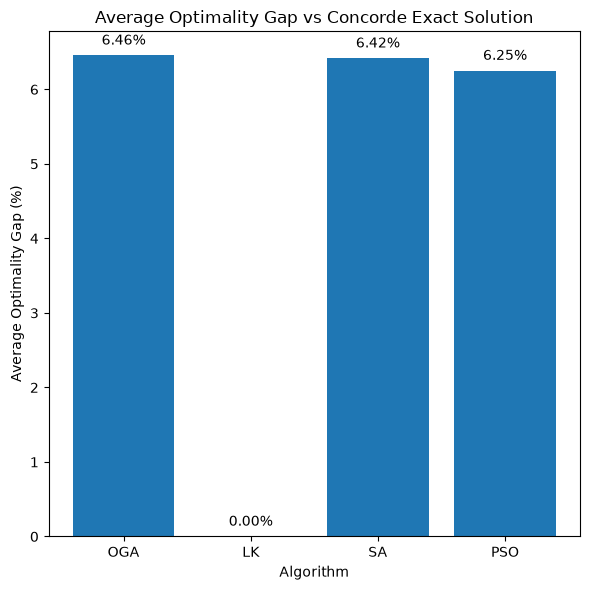

In [34]:
algos = ['OGA', 'LK', 'SA', 'PSO']
avg_gaps = [summary_df[f'{algo}_gap_%'].mean() for algo in algos]
plt.figure(figsize=(6,6))
bars = plt.bar(algos, avg_gaps)

for bar, gap in zip(bars, avg_gaps):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f"{gap:.2f}%", ha="center", va="bottom")
plt.ylabel("Average Optimality Gap (%)")
plt.xlabel("Algorithm")
plt.title("Average Optimality Gap vs Concorde Exact Solution")
plt.tight_layout()
plt.savefig("avg_gap.png")
plt.show()

In [25]:
def add_rankings(df, algos=["OGA","SA","LK","PSO"]):
    cost_cols = [f"[algo]_best_cost" for algo in algos]

    for i, row in df.iterrows():
        costs = {algo: row[f"{algo}_best_cost"] for algo in algos}
        ranked = sorted(costs, key=costs.get)
        for rank, algo in enumerate(ranked):
            df.at[i, f"{algo}_rank"] = rank + 1

    return df

train_df = add_rankings(pd.read_csv("train_meta.csv"))
val_df = add_rankings(pd.read_csv("val_meta.csv"))

In [ ]:
FEATURES = [
    "n_cities",
    "noise_factor",
    "distance_type",
    "triangle_violation_rate",
    "instance_type",
    "avg_edge",
    "std_edge",
    "cv_edge",
    "skew_edge",
    "kurtosis_edge",
    "min_edge",
    "max_edge",
    "avg_nn",
    "std_nn",
    "cv_nn",
    "skew_nn",
    "mst_cost",
    "avg_mst_edge",
    "std_mst_edge",
    "mst_nn_ratio"]

TARGET = "best_algo"
len(FEATURES)

In [17]:
train_df = pd.read_csv("train_meta.csv")
val_df = pd.read_csv("val_meta.csv")

X_train = train_df[FEATURES].fillna(0)
y_train = train_df[TARGET]

X_val = val_df[FEATURES].fillna(0)
y_val = val_df[TARGET]

print(X_train.shape, y_train.unique())

(5760, 20) <StringArray>
['OGA', 'LK', 'SA', 'PSO']
Length: 4, dtype: str


In [22]:
clf = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=90, class_weight="balanced")

clf.fit(X_train, y_train)
cv_scores = cross_val_score(clf, X_train, y_train, cv=5)
print(f"CV Accuracy: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=90)
cv_scores = cross_val_score(clf, X_train, y_train, cv=skf)
print(f"CV Accuracy: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")

CV Accuracy: 0.657 +/- 0.227
CV Accuracy: 0.808 +/- 0.010


Validation Accuracy=0.857
Classification Report
              precision    recall  f1-score   support

          LK       0.98      0.92      0.95      1685
         OGA       0.43      0.43      0.43       126
         PSO       0.32      0.44      0.37        63
          SA       0.14      0.30      0.19        61

    accuracy                           0.86      1935
   macro avg       0.47      0.52      0.49      1935
weighted avg       0.89      0.86      0.87      1935

Confusion Matrix


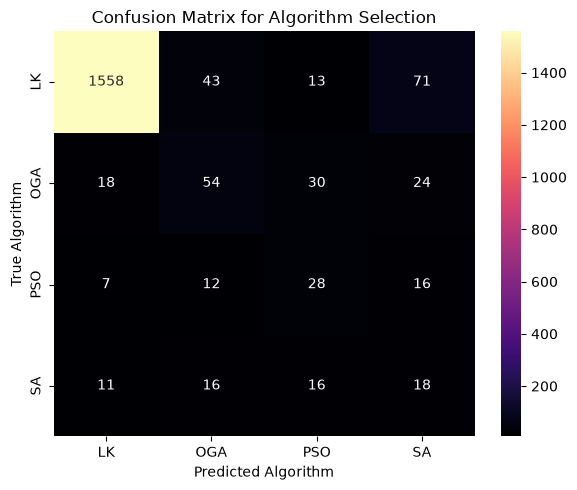

In [25]:
val_preds = clf.predict(X_val)
labels = clf.classes_
print(f"Validation Accuracy={accuracy_score(y_val, val_preds):.3f}")
print("Classification Report")
print(classification_report(y_val, val_preds, zero_division=0))
print("Confusion Matrix")
cm = confusion_matrix(y_val, val_preds, labels=labels)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="magma", xticklabels=labels, yticklabels=labels, cbar=True)
plt.xlabel("Predicted Algorithm")
plt.ylabel("True Algorithm")
plt.title("Confusion Matrix for Algorithm Selection")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()
     

In [26]:
importances = pd.Series(clf.feature_importances_, index=FEATURES).sort_values(ascending=False)
print(importances.head(15))

mst_cost         0.105671
n_cities         0.088769
distance_type    0.065014
cv_edge          0.061806
avg_mst_edge     0.051285
skew_edge        0.050726
max_edge         0.048600
mst_nn_ratio     0.048502
std_mst_edge     0.048444
kurtosis_edge    0.047623
std_edge         0.047247
std_nn           0.045236
noise_factor     0.044993
avg_edge         0.044692
skew_nn          0.042518
dtype: float64


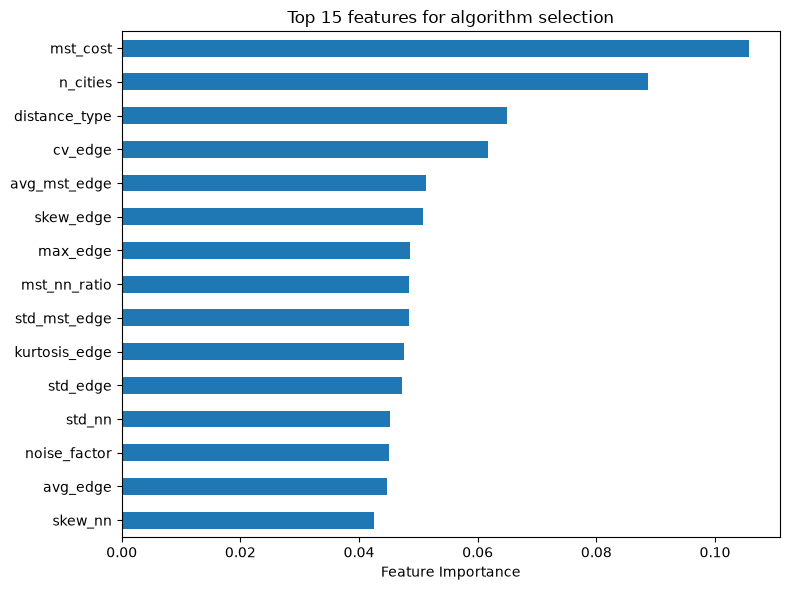

In [27]:
plt.figure(figsize=(8,6))
importances.head(15).sort_values().plot(kind="barh")
plt.xlabel("Feature Importance")
plt.title("Top 15 features for algorithm selection")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()